# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 4 — Supervised Learning Algorithms

This phase evaluates nine supervised algorithms using the Phase 3 training set and the exact five family-aware validation folds. A Dummy Classifier is included only as a reference benchmark.

**The untouched Phase 3 holdout test set is not loaded or evaluated in this phase.**

## Algorithms

1. Logistic Regression
2. K-Nearest Neighbours
3. Support Vector Machine
4. Decision Tree
5. Random Forest
6. Gradient Boosting
7. XGBoost
8. CatBoost
9. Multi-Layer Perceptron

# Section 4.1 — Load Experimental Design and Define Model Framework

In [1]:
# Cell 4.1.1 — Environment and folders
from pathlib import Path
from datetime import datetime
from time import perf_counter
import hashlib, importlib.util, json, random, re, shutil, subprocess, sys, warnings, zipfile

EXECUTION_ENVIRONMENT='COLAB'
RUN_TUNING=True
TUNING_ITERATIONS_PER_MODEL=2
PARALLEL_JOBS=1
RANDOM_STATE=42
AUTO_INSTALL_MISSING_PACKAGES=True
PHASE_3_MANIFEST_OVERRIDE=None
PHASE_3_TRAINING_DATA_OVERRIDE=None
PHASE_3_CV_ASSIGNMENT_OVERRIDE=None
PHASE_3_SCALE_PREPROCESSOR_OVERRIDE=None
PHASE_3_TREE_PREPROCESSOR_OVERRIDE=None

if EXECUTION_ENVIRONMENT=='COLAB':
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT=Path('/content/drive/MyDrive/Jaafar_MSc_Thesis')
    except ImportError:
        PROJECT_ROOT=Path.cwd()
else:
    PROJECT_ROOT=Path.cwd()
DATA_DIR=PROJECT_ROOT/'data'; OUTPUT_ROOT=PROJECT_ROOT/'outputs'
PHASE_3_DIR=OUTPUT_ROOT/'Phase_03_Train_Test_Split_and_Preprocessing_Pipelines'
PHASE_DIR=OUTPUT_ROOT/'Phase_04_Supervised_Learning_Algorithms'
MODEL_DIR=PHASE_DIR/'candidate_models'
for p in [DATA_DIR,OUTPUT_ROOT,PHASE_DIR,MODEL_DIR]: p.mkdir(parents=True,exist_ok=True)
RUN_TIMESTAMP=datetime.now().strftime('%Y-%m-%d_%H-%M-%S'); random.seed(RANDOM_STATE)

def safe_name(x):
    x=str(x).replace('—','-').replace('–','-'); x=re.sub(r'[^\w\-]+','_',x); return re.sub('_+','_',x).strip('_')
def folders(section,title,cell,cell_title):
    base=PHASE_DIR/safe_name(f'Section_{section}_{title}')/safe_name(f'Cell_{cell}_{cell_title}')
    d={k:base/k for k in ['tables','figures','reports','models','files']}
    [p.mkdir(parents=True,exist_ok=True) for p in d.values()]; return d

def save_df(df,d,stem,index=False):
    a=d['tables']/f'{stem}.csv'; b=d['tables']/f'{stem}.xlsx'; df.to_csv(a,index=index,encoding='utf-8-sig');
    if len(df)<=1000: df.to_excel(b,index=index)
    return a,b
def save_json(obj,d,stem):
    p=d['reports']/f'{stem}.json'; p.write_text(json.dumps(obj,ensure_ascii=False,indent=2,default=str),encoding='utf-8'); return p
def sha256_file(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
def load_table(path):
    path=Path(path)
    if path.suffix.lower()=='.csv':
        try: return pd.read_csv(path,encoding='utf-8-sig')
        except UnicodeDecodeError: return pd.read_csv(path,encoding='latin-1')
    return pd.read_excel(path)

D=folders('04_01','Framework','04_01_01','Environment')
save_json({'project_root':str(PROJECT_ROOT),'phase_dir':str(PHASE_DIR),'run_tuning':RUN_TUNING,'iterations':TUNING_ITERATIONS_PER_MODEL,'random_state':RANDOM_STATE,'timestamp':RUN_TIMESTAMP},D,'configuration')
print('Project root:',PROJECT_ROOT)

Project root: C:\Users\User\Desktop\All


In [2]:
# Cell 4.1.2 — Libraries and visual identity
required={'pandas':'pandas','numpy':'numpy','matplotlib':'matplotlib','scipy':'scipy','sklearn':'scikit-learn','joblib':'joblib','openpyxl':'openpyxl','xgboost':'xgboost','catboost':'catboost'}
rows=[]
for imp,pkg in required.items():
    ok=importlib.util.find_spec(imp) is not None
    if not ok and AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg]); status='Installed'
    elif ok: status='Available'
    else: raise ImportError(pkg)
    rows.append({'import_name':imp,'package':pkg,'status':status})
import joblib, matplotlib as mpl, matplotlib.pyplot as plt, numpy as np, pandas as pd, scipy, sklearn, xgboost, catboost
from matplotlib.colors import LinearSegmentedColormap
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,balanced_accuracy_score,confusion_matrix,f1_score,log_loss,precision_recall_fscore_support,precision_score,recall_score,roc_auc_score
from sklearn.model_selection import PredefinedSplit,RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
warnings.filterwarnings('default'); np.random.seed(RANDOM_STATE); pd.set_option('display.max_columns',160); pd.set_option('display.width',210)
THEME={'maroon':'#6B1E32','gold':'#D4A64A','teal':'#237A7A','coral':'#D96850','indigo':'#525B92','sage':'#7A9B76','sand':'#D9C7A3','warm_white':'#F7F4EF','charcoal':'#2E3035','soft_grey':'#D8D5D0'}
MODEL_COLORS={'Dummy Baseline':'#999999','Logistic Regression':THEME['maroon'],'K-Nearest Neighbours':THEME['gold'],'Support Vector Machine':THEME['indigo'],'Decision Tree':THEME['coral'],'Random Forest':THEME['teal'],'Gradient Boosting':THEME['sage'],'XGBoost':'#965D41','CatBoost':'#7A4E9D','Multi-Layer Perceptron':'#3F6F8F'}
mpl.rcParams.update({'figure.facecolor':THEME['warm_white'],'axes.facecolor':THEME['warm_white'],'savefig.facecolor':THEME['warm_white'],'text.color':THEME['charcoal'],'axes.labelcolor':THEME['charcoal'],'axes.titleweight':'bold','axes.titlesize':15,'font.size':10,'legend.frameon':False})
def style_axis(ax,title,subtitle=None,grid='y'):
    ax.set_title(title,loc='left',pad=18,fontweight='bold')
    if subtitle: ax.text(0,1.015,subtitle,transform=ax.transAxes,fontsize=9,color='#5B5B5B')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if grid: ax.grid(axis=grid,alpha=.16); ax.set_axisbelow(True)
def save_fig(fig,d,stem):
    p=d['figures']/f'{stem}.png'; fig.text(.01,.01,'MSc Artificial Intelligence — Bahrain Polytechnic | Phase 4',fontsize=7.5,color='#666'); fig.savefig(p,dpi=300,bbox_inches='tight'); return p
D=folders('04_01','Framework','04_01_02','Libraries')
versions=pd.DataFrame([['Python',sys.version.split()[0]],['pandas',pd.__version__],['numpy',np.__version__],['scikit-learn',sklearn.__version__],['xgboost',xgboost.__version__],['catboost',catboost.__version__]],columns=['library','version'])
save_df(pd.DataFrame(rows),D,'installation_report'); save_df(versions,D,'library_versions'); display(versions)

,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,scikit-learn,1.6.1
4,xgboost,3.2.0
5,catboost,1.2.10


In [3]:
# Cell 4.1.3 — Load Phase 3 training artifacts only
def first_existing(candidates,description):
    for item in candidates:
        if item is None: continue
        p=Path(item).expanduser()
        if p.exists(): return p
    raise FileNotFoundError(description)
manifest_candidates=[PHASE_3_MANIFEST_OVERRIDE,PHASE_3_DIR/'phase_03_handoff_manifest_for_phase_04.json',OUTPUT_ROOT/'phase_03_handoff_manifest_for_phase_04.json',PROJECT_ROOT/'phase_03_handoff_manifest_for_phase_04.json',Path.cwd()/'phase_03_handoff_manifest_for_phase_04.json']
if PHASE_3_DIR.exists(): manifest_candidates+=list(PHASE_3_DIR.rglob('phase_03_handoff_manifest_for_phase_04.json'))
MANIFEST_PATH=first_existing(manifest_candidates,'Phase 3 manifest not found'); manifest=json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
TRAIN_PATH=first_existing([PHASE_3_TRAINING_DATA_OVERRIDE,manifest.get('primary_training_dataset_for_phase_4'),DATA_DIR/'phase_03_training_dataset_for_phase_04.csv',Path.cwd()/'data'/'phase_03_training_dataset_for_phase_04.csv'],'training dataset not found')
CV_PATH=first_existing([PHASE_3_CV_ASSIGNMENT_OVERRIDE,manifest.get('cross_validation_fold_assignment'),DATA_DIR/'phase_03_cross_validation_folds.csv',Path.cwd()/'data'/'phase_03_cross_validation_folds.csv'],'CV assignment not found')
SCALE_PATH=first_existing([PHASE_3_SCALE_PREPROCESSOR_OVERRIDE,manifest.get('scale_sensitive_preprocessor'),Path.cwd()/'phase_03_scale_sensitive_preprocessor_unfitted.joblib'],'scale preprocessor not found')
TREE_PATH=first_existing([PHASE_3_TREE_PREPROCESSOR_OVERRIDE,manifest.get('tree_based_preprocessor'),Path.cwd()/'phase_03_tree_based_preprocessor_unfitted.joblib'],'tree preprocessor not found')
training_data=load_table(TRAIN_PATH); cv_assignment=load_table(CV_PATH); scale_preprocessor=joblib.load(SCALE_PATH); tree_preprocessor=joblib.load(TREE_PATH); protected_holdout=manifest.get('untouched_holdout_test_for_phase_8')
D=folders('04_01','Framework','04_01_03','Load_Artifacts'); save_json({'manifest':str(MANIFEST_PATH),'training':str(TRAIN_PATH),'cv':str(CV_PATH),'training_records':len(training_data),'holdout_recorded_but_not_loaded':protected_holdout,'holdout_loaded':False},D,'loading_report')
print('Training shape:',training_data.shape,'| Holdout loaded:',False)

Training shape: (2006, 20) | Holdout loaded: False


In [4]:
# Cell 4.1.4 — Exact folds, target mapping, and common framework
ID_COLUMN=manifest.get('identifier_column','student_record_id'); GROUP_COLUMN=manifest.get('group_column','family_id'); TARGET_COLUMN=manifest.get('target_column','academic_performance_class'); PREDICTORS=manifest['predictor_columns']; TARGET_CLASSES=manifest.get('target_classes',['Low','Medium','High'])
LABEL_TO_INT={x:i for i,x in enumerate(TARGET_CLASSES)}; INT_TO_LABEL={i:x for x,i in LABEL_TO_INT.items()}
X=training_data[PREDICTORS].copy(); y_text=training_data[TARGET_COLUMN].astype(str); y=y_text.map(LABEL_TO_INT).astype(int); groups=training_data[GROUP_COLUMN]; ids=training_data[ID_COLUMN].astype(str)
fold_map=cv_assignment.set_index(ID_COLUMN)['validation_fold'].astype(int); fold_numbers=ids.map(fold_map)
if fold_numbers.isna().any(): raise ValueError('Missing fold assignment')
predefined_cv=PredefinedSplit(fold_numbers.to_numpy()-1); CV_SPLITS=list(predefined_cv.split())
validation=[]
for fold,(fit_idx,val_idx) in enumerate(CV_SPLITS,1):
    overlap=set(groups.iloc[fit_idx]).intersection(set(groups.iloc[val_idx])); validation.append({'fold':fold,'train_records':len(fit_idx),'validation_records':len(val_idx),'family_overlap':len(overlap),'classes':sorted(y.iloc[val_idx].unique().tolist())})
fold_validation=pd.DataFrame(validation)
if (fold_validation.family_overlap!=0).any(): raise AssertionError('Family overlap')
D=folders('04_01','Framework','04_01_04','Folds'); save_df(fold_validation,D,'fold_validation'); save_df(pd.DataFrame([{'class':k,'code':v} for k,v in LABEL_TO_INT.items()]),D,'target_mapping'); display(fold_validation)
all_fold_results=[]; all_summary_results=[]; all_oof={}; all_confusions={}; all_best_params={}; all_model_paths={}; registry=[]

def probs(estimator,Xv):
    if hasattr(estimator,'predict_proba'):
        raw=estimator.predict_proba(Xv)
    elif hasattr(estimator,'decision_function'):
        scores=np.asarray(estimator.decision_function(Xv),dtype=float)
        if scores.ndim==1: scores=np.column_stack([-scores,scores])
        scores=scores-scores.max(axis=1,keepdims=True)
        exp_scores=np.exp(scores)
        raw=exp_scores/exp_scores.sum(axis=1,keepdims=True)
    else:
        return None
    ordered=np.zeros((len(Xv),3))
    for j,c in enumerate(np.asarray(estimator.classes_,dtype=int)): ordered[:,c]=raw[:,j]
    row_sums=ordered.sum(axis=1,keepdims=True)
    row_sums[row_sums==0]=1.0
    return ordered/row_sums

def evaluate(model_name,stage,template,slug,save_model=True):
    fold_rows=[]; oof_rows=[]; cm=np.zeros((3,3),dtype=int)
    for fold,(fit_idx,val_idx) in enumerate(CV_SPLITS,1):
        est=clone(template); Xf,Xv=X.iloc[fit_idx],X.iloc[val_idx]; yf,yv=y.iloc[fit_idx],y.iloc[val_idx]
        t=perf_counter(); est.fit(Xf,yf); fit_time=perf_counter()-t
        t=perf_counter(); pred=est.predict(Xv); pred_time=perf_counter()-t
        train_f1=f1_score(yf,est.predict(Xf),average='macro',zero_division=0); pr=probs(est,Xv); p,r,f,s=precision_recall_fscore_support(yv,pred,labels=[0,1,2],zero_division=0)
        row={'model':model_name,'stage':stage,'fold':fold,'fit_time_seconds':fit_time,'prediction_time_seconds':pred_time,'accuracy':accuracy_score(yv,pred),'balanced_accuracy':balanced_accuracy_score(yv,pred),'precision_macro':precision_score(yv,pred,average='macro',zero_division=0),'recall_macro':recall_score(yv,pred,average='macro',zero_division=0),'f1_macro':f1_score(yv,pred,average='macro',zero_division=0),'f1_weighted':f1_score(yv,pred,average='weighted',zero_division=0),'training_f1_macro':train_f1}
        for i,n in enumerate(['low','medium','high']): row.update({f'precision_{n}':p[i],f'recall_{n}':r[i],f'f1_{n}':f[i],f'support_{n}':int(s[i])})
        row['roc_auc_ovr_weighted']=roc_auc_score(yv,pr,labels=[0,1,2],multi_class='ovr',average='weighted') if pr is not None else np.nan; row['multiclass_log_loss']=log_loss(yv,pr,labels=[0,1,2]) if pr is not None else np.nan; row['generalisation_gap_f1']=train_f1-row['f1_macro']; fold_rows.append(row); cm+=confusion_matrix(yv,pred,labels=[0,1,2])
        for local_i,data_i in enumerate(val_idx):
            item={ID_COLUMN:ids.iloc[data_i],GROUP_COLUMN:groups.iloc[data_i],'model':model_name,'stage':stage,'fold':fold,'true_encoded':int(yv.iloc[local_i]),'predicted_encoded':int(pred[local_i]),'true_class':INT_TO_LABEL[int(yv.iloc[local_i])],'predicted_class':INT_TO_LABEL[int(pred[local_i])],'correct_prediction':bool(yv.iloc[local_i]==pred[local_i])}
            if pr is not None: item.update({'probability_low':pr[local_i,0],'probability_medium':pr[local_i,1],'probability_high':pr[local_i,2],'prediction_confidence':pr[local_i].max()})
            oof_rows.append(item)
    folds=pd.DataFrame(fold_rows); oof=pd.DataFrame(oof_rows).sort_values(ID_COLUMN); summary={'model':model_name,'stage':stage,'folds':len(folds)}
    metrics=['accuracy','balanced_accuracy','precision_macro','recall_macro','f1_macro','f1_weighted','roc_auc_ovr_weighted','multiclass_log_loss','precision_low','recall_low','f1_low','precision_medium','recall_medium','f1_medium','precision_high','recall_high','f1_high','training_f1_macro','generalisation_gap_f1','fit_time_seconds','prediction_time_seconds']
    for m in metrics: summary[f'mean_{m}']=folds[m].mean(); summary[f'std_{m}']=folds[m].std(ddof=1)
    summary['oof_accuracy']=accuracy_score(oof.true_encoded,oof.predicted_encoded); summary['oof_f1_macro']=f1_score(oof.true_encoded,oof.predicted_encoded,average='macro',zero_division=0)
    model_path=None
    if save_model:
        full=clone(template); full.fit(X,y); model_path=MODEL_DIR/f'{slug}_{stage.lower()}_full_training.joblib'; joblib.dump(full,model_path)
    return {'folds':folds,'summary':pd.DataFrame([summary]),'oof':oof,'cm':cm,'model_path':model_path}

def run_model(model_name,slug,section,template,space):
    D=folders(section,slug,f'{section}_99','Outputs'); baseline=evaluate(model_name,'Baseline',template,slug); save_df(baseline['folds'],D,f'{slug}_baseline_folds'); save_df(baseline['summary'],D,f'{slug}_baseline_summary'); save_df(baseline['oof'],D,f'{slug}_baseline_oof'); all_fold_results.append(baseline['folds']); all_summary_results.append(baseline['summary']); all_oof[(model_name,'Baseline')]=baseline['oof']; all_confusions[(model_name,'Baseline')]=baseline['cm']; all_model_paths[(model_name,'Baseline')]=str(baseline['model_path'])
    tuned=None
    if RUN_TUNING:
        n_iter=min(TUNING_ITERATIONS_PER_MODEL,int(np.prod([len(v) for v in space.values()]))); search=RandomizedSearchCV(clone(template),space,n_iter=n_iter,scoring='f1_macro',n_jobs=PARALLEL_JOBS,cv=predefined_cv,refit=True,random_state=RANDOM_STATE,return_train_score=True,error_score='raise'); t=perf_counter(); search.fit(X,y); search_time=perf_counter()-t; search_results=pd.DataFrame(search.cv_results_).sort_values('rank_test_score'); tuned_template=clone(template).set_params(**search.best_params_); tuned=evaluate(model_name,'Tuned',tuned_template,slug); save_df(search_results,D,f'{slug}_search_results'); save_json({'best_score':search.best_score_,'best_params':search.best_params_,'search_time_seconds':search_time,'iterations':n_iter},D,f'{slug}_best_parameters'); save_df(tuned['folds'],D,f'{slug}_tuned_folds'); save_df(tuned['summary'],D,f'{slug}_tuned_summary'); save_df(tuned['oof'],D,f'{slug}_tuned_oof'); all_fold_results.append(tuned['folds']); all_summary_results.append(tuned['summary']); all_oof[(model_name,'Tuned')]=tuned['oof']; all_confusions[(model_name,'Tuned')]=tuned['cm']; all_best_params[model_name]=search.best_params_; all_model_paths[(model_name,'Tuned')]=str(tuned['model_path'])
    comparison=pd.concat([baseline['summary'],tuned['summary'] if tuned else pd.DataFrame()],ignore_index=True); best=comparison.sort_values(['mean_f1_macro','mean_balanced_accuracy'],ascending=False).iloc[0]; registry.append({'model':model_name,'slug':slug,'baseline_path':str(baseline['model_path']),'tuned_path':str(tuned['model_path']) if tuned else None,'recommended_stage':best.stage,'recommended_macro_f1':best.mean_f1_macro,'recommended_balanced_accuracy':best.mean_balanced_accuracy}); display(comparison[['model','stage','mean_f1_macro','std_f1_macro','mean_balanced_accuracy','mean_accuracy','mean_recall_low','mean_recall_medium','mean_recall_high','mean_fit_time_seconds']].round(4)); return comparison

,fold,train_records,validation_records,family_overlap,classes
0,1,1602,404,0,"[0, 1, 2]"
1,2,1602,404,0,"[0, 1, 2]"
2,3,1593,413,0,"[0, 1, 2]"
3,4,1593,413,0,"[0, 1, 2]"
4,5,1634,372,0,"[0, 1, 2]"


In [5]:
# Cell 4.1.5 — Dummy reference benchmark
dummy=evaluate('Dummy Baseline','Reference',Pipeline([('preprocessing',clone(tree_preprocessor)),('model',DummyClassifier(strategy='prior',random_state=RANDOM_STATE))]),'dummy',False); all_fold_results.append(dummy['folds']); all_summary_results.append(dummy['summary']); all_oof[('Dummy Baseline','Reference')]=dummy['oof']; all_confusions[('Dummy Baseline','Reference')]=dummy['cm']; display(dummy['summary'][['mean_accuracy','mean_balanced_accuracy','mean_f1_macro']].round(4))

,mean_accuracy,mean_balanced_accuracy,mean_f1_macro
0,0.4953,0.3333,0.2207


# Section 4.2 — Logistic Regression

**Purpose:** Linear multiclass classification with scaled features.

In [6]:
# Cell 4.2.1 — Logistic Regression
model=Pipeline([('preprocessing',clone(scale_preprocessor)),('model',LogisticRegression(max_iter=2500,solver='lbfgs',random_state=RANDOM_STATE))]); space={'model__C':[.01,.05,.1,.5,1,2,5,10],'model__class_weight':[None,'balanced']}; logistic_results=run_model('Logistic Regression','logistic_regression','04_02',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Logistic Regression,Baseline,0.5528,0.0219,0.5383,0.5890,0.5070,0.7488,0.3592,0.2422
1,Logistic Regression,Tuned,0.5114,0.0227,0.5027,0.5813,0.4363,0.8282,0.2435,0.0922


# Section 4.3 — K-Nearest Neighbours

**Purpose:** Distance-based classification with scaled features.

In [7]:
# Cell 4.3.1 — KNN
model=Pipeline([('preprocessing',clone(scale_preprocessor)),('model',KNeighborsClassifier(n_neighbors=5,algorithm='ball_tree',leaf_size=30,n_jobs=1))]); space={'model__n_neighbors':[3,5,7,9,11,15,21,31],'model__weights':['uniform','distance'],'model__p':[1,2]}; knn_results=run_model('K-Nearest Neighbours','knn','04_03',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,K-Nearest Neighbours,Baseline,0.4746,0.0212,0.4677,0.5027,0.4151,0.6108,0.3772,0.0257
1,K-Nearest Neighbours,Tuned,0.5026,0.0207,0.4893,0.5561,0.3697,0.7688,0.3294,0.0274


# Section 4.4 — Support Vector Machine

**Purpose:** Margin-based classification with probability estimates.

In [8]:
# Cell 4.4.1 — SVM
model=Pipeline([('preprocessing',clone(scale_preprocessor)),('model',SVC(probability=False,random_state=RANDOM_STATE))]); space={'model__C':[.1,.5,1,2,5,10],'model__kernel':['rbf','linear'],'model__gamma':['scale','auto',.01,.05,.1],'model__class_weight':[None,'balanced']}; svm_results=run_model('Support Vector Machine','svm','04_04',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Support Vector Machine,Baseline,0.5098,0.0304,0.4993,0.5741,0.4304,0.8086,0.2587,0.1605
1,Support Vector Machine,Tuned,0.4828,0.0273,0.4917,0.5759,0.4960,0.8433,0.1359,0.1580


# Section 4.5 — Decision Tree

**Purpose:** Interpretable nonlinear tree classification.

In [9]:
# Cell 4.5.1 — Decision Tree
model=Pipeline([('preprocessing',clone(tree_preprocessor)),('model',DecisionTreeClassifier(random_state=RANDOM_STATE))]); space={'model__criterion':['gini','entropy','log_loss'],'model__max_depth':[None,4,6,8,10,14],'model__min_samples_split':[2,5,10,20],'model__min_samples_leaf':[1,2,4,8],'model__class_weight':[None,'balanced']}; dt_results=run_model('Decision Tree','decision_tree','04_05',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Decision Tree,Baseline,0.4641,0.0310,0.4674,0.4777,0.5037,0.5128,0.3859,0.0295
1,Decision Tree,Tuned,0.4882,0.0325,0.5378,0.4823,0.6550,0.3076,0.6510,0.0266


# Section 4.6 — Random Forest

**Purpose:** Bagged tree ensemble classification.

In [10]:
# Cell 4.6.1 — Random Forest
model=Pipeline([('preprocessing',clone(tree_preprocessor)),('model',RandomForestClassifier(n_estimators=150,n_jobs=1,random_state=RANDOM_STATE))]); space={'model__n_estimators':[100,150,250],'model__max_depth':[None,6,10,14,20],'model__min_samples_split':[2,5,10],'model__min_samples_leaf':[1,2,4],'model__max_features':['sqrt','log2',.7],'model__class_weight':[None,'balanced','balanced_subsample']}; rf_results=run_model('Random Forest','random_forest','04_06',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Random Forest,Baseline,0.5232,0.025,0.5118,0.5591,0.4601,0.7134,0.3620,0.4685
1,Random Forest,Tuned,0.5419,0.011,0.5681,0.5368,0.6616,0.4349,0.6077,0.6587


# Section 4.7 — Gradient Boosting

**Purpose:** Sequential boosting with weak decision trees.

In [11]:
# Cell 4.7.1 — Gradient Boosting
model=Pipeline([('preprocessing',clone(tree_preprocessor)),('model',GradientBoostingClassifier(random_state=RANDOM_STATE))]); space={'model__n_estimators':[60,100,150],'model__learning_rate':[.03,.05,.1,.2],'model__max_depth':[1,2,3,4],'model__min_samples_leaf':[1,2,4,8],'model__subsample':[.7,.85,1]}; gb_results=run_model('Gradient Boosting','gradient_boosting','04_07',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Gradient Boosting,Baseline,0.5392,0.0265,0.5275,0.5724,0.4943,0.7158,0.3724,0.7588
1,Gradient Boosting,Tuned,0.5407,0.0229,0.5278,0.5745,0.4954,0.7247,0.3633,0.3761


# Section 4.8 — XGBoost

**Purpose:** Histogram-based boosted tree classification.

In [12]:
# Cell 4.8.1 — XGBoost
model=Pipeline([('preprocessing',clone(tree_preprocessor)),('model',XGBClassifier(objective='multi:softprob',num_class=3,eval_metric='mlogloss',n_estimators=120,max_depth=6,learning_rate=.1,tree_method='hist',n_jobs=1,random_state=RANDOM_STATE))]); space={'model__n_estimators':[80,120,180],'model__max_depth':[3,4,5,6,8],'model__learning_rate':[.03,.05,.1,.2],'model__subsample':[.7,.85,1],'model__colsample_bytree':[.7,.85,1],'model__min_child_weight':[1,3,5],'model__reg_lambda':[.5,1,2,5]}; xgb_results=run_model('XGBoost','xgboost','04_08',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,XGBoost,Baseline,0.5233,0.0180,0.5130,0.5538,0.4797,0.6862,0.3732,0.1936
1,XGBoost,Tuned,0.5396,0.0187,0.5267,0.5732,0.4951,0.7202,0.3650,0.1831


# Section 4.9 — CatBoost

**Purpose:** Boosted tree classification on the shared transformed feature space.

In [13]:
# Cell 4.9.1 — CatBoost with a Compatible Preprocessor Bundle
from sklearn.model_selection import ParameterSampler

catboost_base_params={
    'iterations':150,'depth':6,'learning_rate':0.08,
    'loss_function':'MultiClass','verbose':False,
    'allow_writing_files':False,'thread_count':1,
    'random_seed':RANDOM_STATE,
}
catboost_space={
    'iterations':[100,150,250],
    'depth':[4,6,8,10],
    'learning_rate':[0.03,0.05,0.1,0.15],
    'l2_leaf_reg':[1,3,5,8],
    'random_strength':[0.5,1.0,2.0],
}

def evaluate_catboost(stage,params):
    fold_rows=[]; oof_rows=[]; total_cm=np.zeros((3,3),dtype=int)
    for fold,(fit_idx,val_idx) in enumerate(CV_SPLITS,1):
        pre=clone(tree_preprocessor)
        Xf=pre.fit_transform(X.iloc[fit_idx]); Xv=pre.transform(X.iloc[val_idx])
        yf=y.iloc[fit_idx]; yv=y.iloc[val_idx]
        model=CatBoostClassifier(**params)
        t=perf_counter(); model.fit(Xf,yf); fit_time=perf_counter()-t
        t=perf_counter(); pred=np.asarray(model.predict(Xv)).reshape(-1).astype(int); pred_time=perf_counter()-t
        train_pred=np.asarray(model.predict(Xf)).reshape(-1).astype(int)
        train_f1=f1_score(yf,train_pred,average='macro',zero_division=0)
        pr=np.asarray(model.predict_proba(Xv),dtype=float)
        pr=pr/pr.sum(axis=1,keepdims=True)
        p,r,f,s=precision_recall_fscore_support(yv,pred,labels=[0,1,2],zero_division=0)
        row={'model':'CatBoost','stage':stage,'fold':fold,'fit_time_seconds':fit_time,'prediction_time_seconds':pred_time,'accuracy':accuracy_score(yv,pred),'balanced_accuracy':balanced_accuracy_score(yv,pred),'precision_macro':precision_score(yv,pred,average='macro',zero_division=0),'recall_macro':recall_score(yv,pred,average='macro',zero_division=0),'f1_macro':f1_score(yv,pred,average='macro',zero_division=0),'f1_weighted':f1_score(yv,pred,average='weighted',zero_division=0),'training_f1_macro':train_f1}
        for i,n in enumerate(['low','medium','high']):
            row.update({f'precision_{n}':p[i],f'recall_{n}':r[i],f'f1_{n}':f[i],f'support_{n}':int(s[i])})
        row['roc_auc_ovr_weighted']=roc_auc_score(yv,pr,labels=[0,1,2],multi_class='ovr',average='weighted')
        row['multiclass_log_loss']=log_loss(yv,pr,labels=[0,1,2])
        row['generalisation_gap_f1']=train_f1-row['f1_macro']
        fold_rows.append(row); total_cm+=confusion_matrix(yv,pred,labels=[0,1,2])
        for local_i,data_i in enumerate(val_idx):
            oof_rows.append({ID_COLUMN:ids.iloc[data_i],GROUP_COLUMN:groups.iloc[data_i],'model':'CatBoost','stage':stage,'fold':fold,'true_encoded':int(yv.iloc[local_i]),'predicted_encoded':int(pred[local_i]),'true_class':INT_TO_LABEL[int(yv.iloc[local_i])],'predicted_class':INT_TO_LABEL[int(pred[local_i])],'correct_prediction':bool(yv.iloc[local_i]==pred[local_i]),'probability_low':pr[local_i,0],'probability_medium':pr[local_i,1],'probability_high':pr[local_i,2],'prediction_confidence':pr[local_i].max()})
    fold_df=pd.DataFrame(fold_rows); oof_df=pd.DataFrame(oof_rows).sort_values(ID_COLUMN)
    summary={'model':'CatBoost','stage':stage,'folds':len(fold_df)}
    metrics=['accuracy','balanced_accuracy','precision_macro','recall_macro','f1_macro','f1_weighted','roc_auc_ovr_weighted','multiclass_log_loss','precision_low','recall_low','f1_low','precision_medium','recall_medium','f1_medium','precision_high','recall_high','f1_high','training_f1_macro','generalisation_gap_f1','fit_time_seconds','prediction_time_seconds']
    for metric in metrics:
        summary[f'mean_{metric}']=fold_df[metric].mean(); summary[f'std_{metric}']=fold_df[metric].std(ddof=1)
    summary['oof_accuracy']=accuracy_score(oof_df.true_encoded,oof_df.predicted_encoded)
    summary['oof_f1_macro']=f1_score(oof_df.true_encoded,oof_df.predicted_encoded,average='macro',zero_division=0)
    full_pre=clone(tree_preprocessor); full_X=full_pre.fit_transform(X)
    full_model=CatBoostClassifier(**params); full_model.fit(full_X,y)
    model_path=MODEL_DIR/f"catboost_{stage.lower()}_full_training.joblib"
    joblib.dump({'preprocessor':full_pre,'model':full_model,'target_mapping':LABEL_TO_INT,'predictors':PREDICTORS},model_path)
    return {'folds':fold_df,'summary':pd.DataFrame([summary]),'oof':oof_df,'cm':total_cm,'model_path':model_path}

def score_catboost_candidate(params):
    scores=[]
    for fit_idx,val_idx in CV_SPLITS:
        pre=clone(tree_preprocessor)
        Xf=pre.fit_transform(X.iloc[fit_idx]); Xv=pre.transform(X.iloc[val_idx])
        model=CatBoostClassifier(**params); model.fit(Xf,y.iloc[fit_idx])
        pred=np.asarray(model.predict(Xv)).reshape(-1).astype(int)
        scores.append(f1_score(y.iloc[val_idx],pred,average='macro',zero_division=0))
    return float(np.mean(scores))

D=folders('04_09','catboost','04_09_99','Outputs')
cat_baseline=evaluate_catboost('Baseline',catboost_base_params)
save_df(cat_baseline['folds'],D,'catboost_baseline_folds'); save_df(cat_baseline['summary'],D,'catboost_baseline_summary'); save_df(cat_baseline['oof'],D,'catboost_baseline_oof')
all_fold_results.append(cat_baseline['folds']); all_summary_results.append(cat_baseline['summary']); all_oof[('CatBoost','Baseline')]=cat_baseline['oof']; all_confusions[('CatBoost','Baseline')]=cat_baseline['cm']; all_model_paths[('CatBoost','Baseline')]=str(cat_baseline['model_path'])

candidates=list(ParameterSampler(catboost_space,n_iter=min(TUNING_ITERATIONS_PER_MODEL,2),random_state=RANDOM_STATE))
search_rows=[]; t=perf_counter()
for candidate_number,candidate in enumerate(candidates,1):
    candidate_params={**catboost_base_params,**candidate}
    search_rows.append({'candidate':candidate_number,'mean_test_score':score_catboost_candidate(candidate_params),**{f'param_{k}':v for k,v in candidate.items()}})
search_time=perf_counter()-t
cat_search=pd.DataFrame(search_rows).sort_values('mean_test_score',ascending=False)
best_number=int(cat_search.iloc[0]['candidate'])
best_raw=candidates[best_number-1]
best_params={**catboost_base_params,**best_raw}
save_df(cat_search,D,'catboost_search_results'); save_json({'best_score':float(cat_search.iloc[0].mean_test_score),'best_params':best_raw,'search_time_seconds':search_time,'iterations':len(candidates)},D,'catboost_best_parameters')
cat_tuned=evaluate_catboost('Tuned',best_params)
save_df(cat_tuned['folds'],D,'catboost_tuned_folds'); save_df(cat_tuned['summary'],D,'catboost_tuned_summary'); save_df(cat_tuned['oof'],D,'catboost_tuned_oof')
all_fold_results.append(cat_tuned['folds']); all_summary_results.append(cat_tuned['summary']); all_oof[('CatBoost','Tuned')]=cat_tuned['oof']; all_confusions[('CatBoost','Tuned')]=cat_tuned['cm']; all_best_params['CatBoost']=best_raw; all_model_paths[('CatBoost','Tuned')]=str(cat_tuned['model_path'])
comparison=pd.concat([cat_baseline['summary'],cat_tuned['summary']],ignore_index=True)
best=comparison.sort_values(['mean_f1_macro','mean_balanced_accuracy'],ascending=False).iloc[0]
registry.append({'model':'CatBoost','slug':'catboost','baseline_path':str(cat_baseline['model_path']),'tuned_path':str(cat_tuned['model_path']),'recommended_stage':best.stage,'recommended_macro_f1':best.mean_f1_macro,'recommended_balanced_accuracy':best.mean_balanced_accuracy})
display(comparison[['model','stage','mean_f1_macro','std_f1_macro','mean_balanced_accuracy','mean_accuracy','mean_recall_low','mean_recall_medium','mean_recall_high','mean_fit_time_seconds']].round(4))

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,CatBoost,Baseline,0.5328,0.0133,0.5196,0.5696,0.4747,0.7262,0.3578,0.3507
1,CatBoost,Tuned,0.5416,0.0290,0.5295,0.5760,0.4893,0.7240,0.3753,0.3378


# Section 4.10 — Multi-Layer Perceptron

**Purpose:** Feed-forward neural network with scaled inputs and early stopping.

In [14]:
# Cell 4.10.1 — MLP
model=Pipeline([('preprocessing',clone(scale_preprocessor)),('model',MLPClassifier(hidden_layer_sizes=(64,),max_iter=300,early_stopping=True,validation_fraction=.15,n_iter_no_change=25,random_state=RANDOM_STATE))]); space={'model__hidden_layer_sizes':[(32,),(64,),(128,),(64,32),(128,64),(64,32,16)],'model__activation':['relu','tanh'],'model__alpha':[.0001,.001,.01],'model__learning_rate_init':[.0005,.001,.003,.01]}; mlp_results=run_model('Multi-Layer Perceptron','mlp','04_10',model,space)

,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_fit_time_seconds
0,Multi-Layer Perceptron,Baseline,0.5236,0.0328,0.5128,0.5717,0.4793,0.7526,0.3066,1.1200
1,Multi-Layer Perceptron,Tuned,0.5410,0.0296,0.5327,0.5749,0.5429,0.7048,0.3505,1.6375


# Section 4.11 — Supervised Model Results Consolidation

In [15]:
# Cell 4.11.1 — Consolidate results and create leaderboard
all_folds=pd.concat(all_fold_results,ignore_index=True); all_summaries=pd.concat(all_summary_results,ignore_index=True); model_registry=pd.DataFrame(registry); params=pd.DataFrame([{'model':m,'parameter':k,'best_value':str(v)} for m,d in all_best_params.items() for k,v in d.items()])
candidates=all_summaries[all_summaries.model!='Dummy Baseline'].copy(); candidates['stage_tiebreak']=candidates.stage.map({'Tuned':0,'Baseline':1}); best_stage=candidates.sort_values(['model','mean_f1_macro','mean_balanced_accuracy','stage_tiebreak'],ascending=[True,False,False,True]).groupby('model',as_index=False).first(); leaderboard=best_stage.sort_values(['mean_f1_macro','mean_balanced_accuracy','std_f1_macro','mean_fit_time_seconds'],ascending=[False,False,True,True]).reset_index(drop=True); leaderboard.insert(0,'rank',np.arange(1,len(leaderboard)+1)); leaderboard['recommended_model_path']=leaderboard.apply(lambda r:all_model_paths[(r.model,r.stage)],axis=1); leaderboard['selected_for_phase_6']=leaderboard['rank']<=4
base=all_summaries[all_summaries.stage=='Baseline'].set_index('model'); tuned=all_summaries[all_summaries.stage=='Tuned'].set_index('model'); improvement=pd.DataFrame([{'model':m,'baseline_macro_f1':base.loc[m,'mean_f1_macro'],'tuned_macro_f1':tuned.loc[m,'mean_f1_macro'],'macro_f1_improvement':tuned.loc[m,'mean_f1_macro']-base.loc[m,'mean_f1_macro']} for m in sorted(set(base.index)&set(tuned.index))]); combined_oof=pd.concat(list(all_oof.values()),ignore_index=True)
confusion_rows=[]
for (m,s),matrix in all_confusions.items():
    for i,t in enumerate(TARGET_CLASSES):
        for j,p in enumerate(TARGET_CLASSES): confusion_rows.append({'model':m,'stage':s,'true_class':t,'predicted_class':p,'record_count':int(matrix[i,j])})
combined_confusions=pd.DataFrame(confusion_rows); D=folders('04_11','Consolidation','04_11_01','Leaderboard')
for df,name in [(all_folds,'all_fold_results'),(all_summaries,'all_summary_results'),(model_registry,'model_registry'),(params,'best_parameters'),(improvement,'tuning_improvement'),(combined_oof,'all_oof_predictions'),(combined_confusions,'confusion_matrices'),(leaderboard,'leaderboard')]: save_df(df,D,name)
display(leaderboard[['rank','model','stage','mean_f1_macro','std_f1_macro','mean_balanced_accuracy','mean_accuracy','mean_recall_low','mean_recall_medium','mean_recall_high','mean_generalisation_gap_f1','mean_fit_time_seconds','selected_for_phase_6']].round(4))

,rank,model,stage,mean_f1_macro,std_f1_macro,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high,mean_generalisation_gap_f1,mean_fit_time_seconds,selected_for_phase_6
0,1,Logistic Regression,Baseline,0.5528,0.0219,0.5383,0.5890,0.5070,0.7488,0.3592,0.0110,0.2422,True
1,2,Random Forest,Tuned,0.5419,0.0110,0.5681,0.5368,0.6616,0.4349,0.6077,0.1915,0.6587,True
2,3,CatBoost,Tuned,0.5416,0.0290,0.5295,0.5760,0.4893,0.7240,0.3753,0.1811,0.3378,True
3,4,Multi-Layer Perceptron,Tuned,0.5410,0.0296,0.5327,0.5749,0.5429,0.7048,0.3505,0.0262,1.6375,True
4,5,Gradient Boosting,Tuned,0.5407,0.0229,0.5278,0.5745,0.4954,0.7247,0.3633,0.0318,0.3761,False
5,6,XGBoost,Tuned,0.5396,0.0187,0.5267,0.5732,0.4951,0.7202,0.3650,0.1749,0.1831,False
6,7,Support Vector Machine,Baseline,0.5098,0.0304,0.4993,0.5741,0.4304,0.8086,0.2587,0.0857,0.1605,False
7,8,K-Nearest Neighbours,Tuned,0.5026,0.0207,0.4893,0.5561,0.3697,0.7688,0.3294,0.4944,0.0274,False
8,9,Decision Tree,Tuned,0.4882,0.0325,0.5378,0.4823,0.6550,0.3076,0.6510,0.1089,0.0266,False


# Section 4.12 — Multiple Visualization: Supervised Models

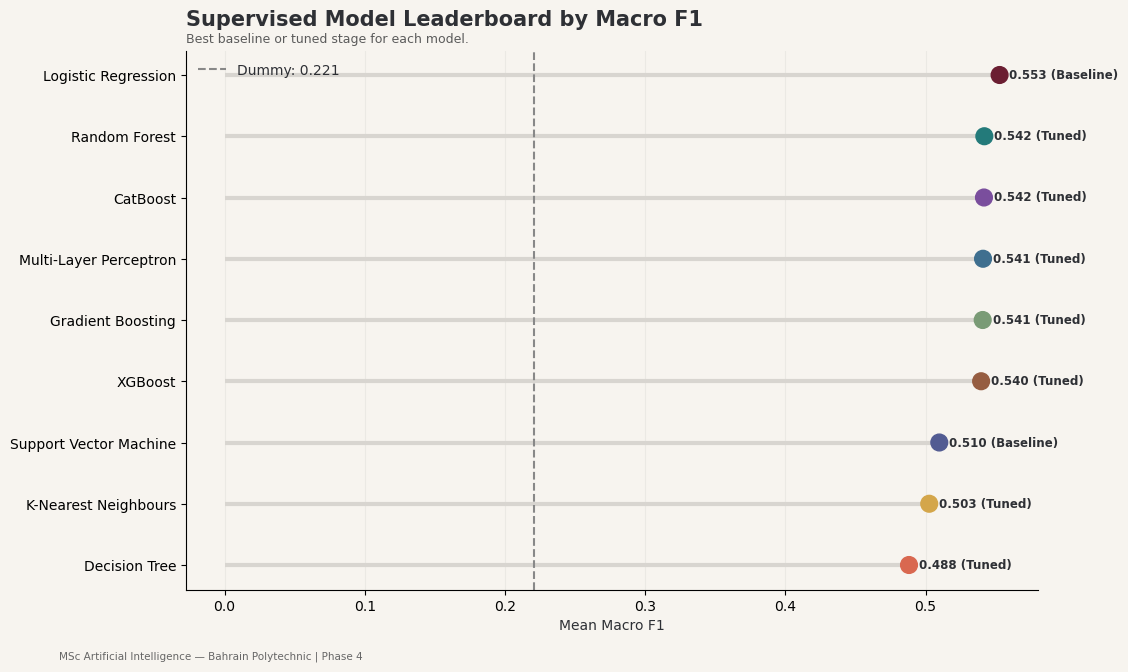

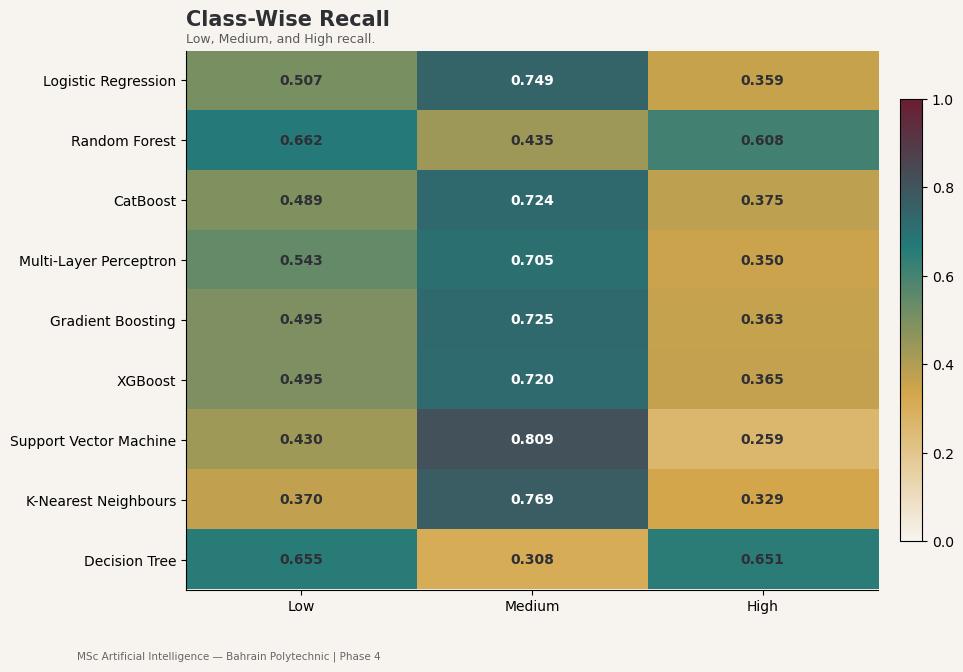

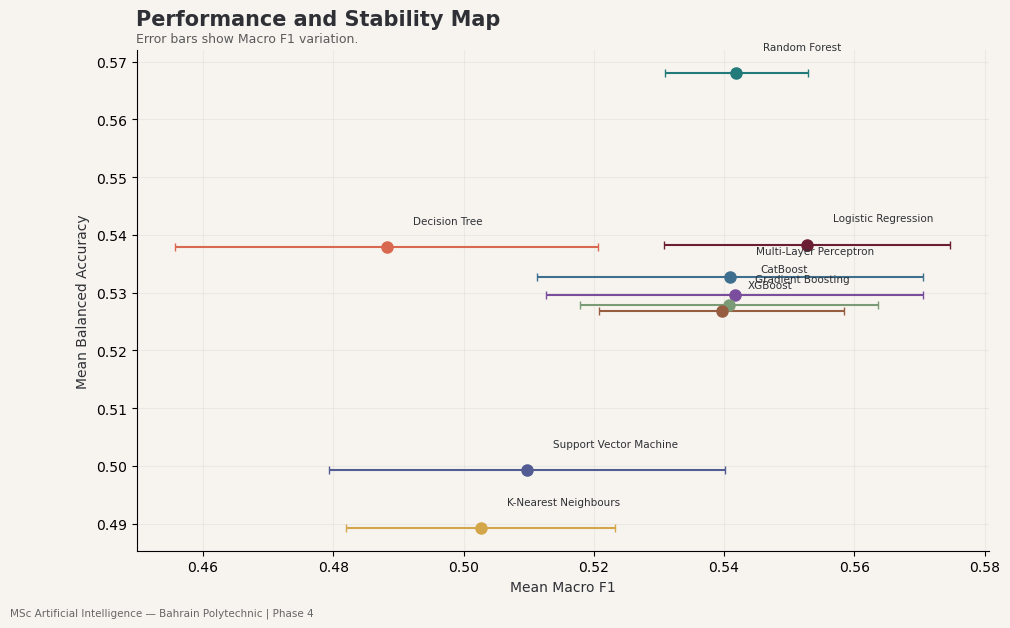

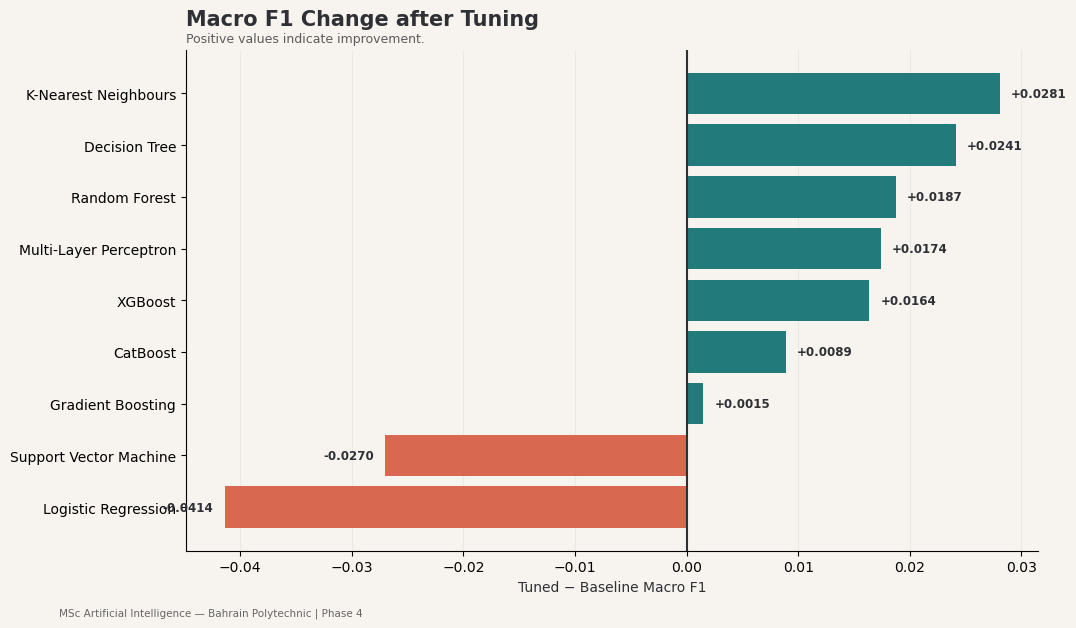

In [16]:
# Cell 4.12.1 — Model comparison figures
D=folders('04_12','Visualisation','04_12_01','Figures'); plot=leaderboard.sort_values('mean_f1_macro'); dummy_f1=float(all_summaries.loc[all_summaries.model=='Dummy Baseline','mean_f1_macro'].iloc[0])
fig,ax=plt.subplots(figsize=(11,7)); ax.hlines(plot.model,0,plot.mean_f1_macro,color=THEME['soft_grey'],linewidth=3); ax.scatter(plot.mean_f1_macro,plot.model,s=145,color=[MODEL_COLORS[m] for m in plot.model],zorder=3)
for _,r in plot.iterrows(): ax.text(r.mean_f1_macro+.007,r.model,f'{r.mean_f1_macro:.3f} ({r.stage})',va='center',fontsize=8.5,fontweight='bold')
ax.axvline(dummy_f1,ls='--',color='#888',label=f'Dummy: {dummy_f1:.3f}'); style_axis(ax,'Supervised Model Leaderboard by Macro F1','Best baseline or tuned stage for each model.','x'); ax.set_xlabel('Mean Macro F1'); ax.legend(); save_fig(fig,D,'model_leaderboard'); plt.show()
recall=leaderboard.set_index('model')[['mean_recall_low','mean_recall_medium','mean_recall_high']]; recall.columns=['Low','Medium','High']; vals=recall.to_numpy(); fig,ax=plt.subplots(figsize=(9.5,7)); im=ax.imshow(vals,aspect='auto',vmin=0,vmax=1,cmap=LinearSegmentedColormap.from_list('recall',[THEME['warm_white'],THEME['gold'],THEME['teal'],THEME['maroon']])); ax.set_xticks(range(3),recall.columns); ax.set_yticks(range(len(recall)),recall.index)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]): ax.text(j,i,f'{vals[i,j]:.3f}',ha='center',va='center',fontweight='bold',color='white' if vals[i,j]>=.68 else THEME['charcoal'])
style_axis(ax,'Class-Wise Recall','Low, Medium, and High recall.',None); fig.colorbar(im,ax=ax,fraction=.03,pad=.03); save_fig(fig,D,'class_recall_heatmap'); plt.show()
fig,ax=plt.subplots(figsize=(11,6.5))
for _,r in leaderboard.iterrows(): ax.errorbar(r.mean_f1_macro,r.mean_balanced_accuracy,xerr=r.std_f1_macro,fmt='o',capsize=3,markersize=8,color=MODEL_COLORS[r.model]); ax.text(r.mean_f1_macro+.004,r.mean_balanced_accuracy+.004,r.model,fontsize=7.5)
style_axis(ax,'Performance and Stability Map','Error bars show Macro F1 variation.','both'); ax.set_xlabel('Mean Macro F1'); ax.set_ylabel('Mean Balanced Accuracy'); save_fig(fig,D,'performance_stability'); plt.show()
imp=improvement.sort_values('macro_f1_improvement'); fig,ax=plt.subplots(figsize=(11,6.5)); bars=ax.barh(imp.model,imp.macro_f1_improvement,color=[THEME['teal'] if x>=0 else THEME['coral'] for x in imp.macro_f1_improvement]); ax.axvline(0,color=THEME['charcoal'])
for b,v in zip(bars,imp.macro_f1_improvement): ax.text(v+(.001 if v>=0 else -.001),b.get_y()+b.get_height()/2,f'{v:+.4f}',va='center',ha='left' if v>=0 else 'right',fontweight='bold',fontsize=8.5)
style_axis(ax,'Macro F1 Change after Tuning','Positive values indicate improvement.','x'); ax.set_xlabel('Tuned − Baseline Macro F1'); save_fig(fig,D,'tuning_improvement'); plt.show()

In [17]:
# Cell 4.12.2 — Visualisation catalogue
D=folders('04_12','Visualisation','04_12_02','Catalogue'); figs=sorted(PHASE_DIR.rglob('*.png')); visual_catalogue=pd.DataFrame([{'figure_number':i,'figure_name':p.stem,'relative_path':str(p.relative_to(PHASE_DIR)),'file_size_kb':round(p.stat().st_size/1024,2)} for i,p in enumerate(figs,1)]); save_df(visual_catalogue,D,'visualisation_catalogue'); display(visual_catalogue)

,figure_number,figure_name,relative_path,file_size_kb
0,1,class_recall_heatmap,Section_04_12_Visualisation\Cell_04_12_01_Figu...,250.76
1,2,model_leaderboard,Section_04_12_Visualisation\Cell_04_12_01_Figu...,259.04
2,3,performance_stability,Section_04_12_Visualisation\Cell_04_12_01_Figu...,191.81
3,4,tuning_improvement,Section_04_12_Visualisation\Cell_04_12_01_Figu...,201.66


# Section 4.13 — Export Multiple Files and Phase Handoff

In [18]:
# Cell 4.13.1 — Official result files and workbook
D=folders('04_13','Export','04_13_01','Official_Results'); official={'leaderboard':DATA_DIR/'phase_04_supervised_model_leaderboard.csv','fold_results':DATA_DIR/'phase_04_all_fold_results.csv','summary_results':DATA_DIR/'phase_04_all_summary_results.csv','oof_predictions':DATA_DIR/'phase_04_all_oof_predictions.csv','model_registry':DATA_DIR/'phase_04_model_registry.csv','best_parameters':DATA_DIR/'phase_04_best_hyperparameters.csv'}
for df,key in [(leaderboard,'leaderboard'),(all_folds,'fold_results'),(all_summaries,'summary_results'),(combined_oof,'oof_predictions'),(model_registry,'model_registry'),(params,'best_parameters')]: df.to_csv(official[key],index=False,encoding='utf-8-sig'); shutil.copy2(official[key],D['files']/official[key].name)
workbook=D['files']/'phase_04_consolidated_reports.xlsx'
with pd.ExcelWriter(workbook,engine='openpyxl') as writer:
    versions.to_excel(writer,'Library_Versions',index=False); fold_validation.to_excel(writer,'CV_Validation',index=False); all_folds.to_excel(writer,'All_Fold_Results',index=False); all_summaries.to_excel(writer,'All_Summaries',index=False); leaderboard.to_excel(writer,'Leaderboard',index=False); improvement.to_excel(writer,'Tuning_Improvement',index=False); params.to_excel(writer,'Best_Parameters',index=False); model_registry.to_excel(writer,'Model_Registry',index=False); combined_confusions.to_excel(writer,'Confusion_Matrices',index=False); visual_catalogue.to_excel(writer,'Visual_Catalogue',index=False)
print('Workbook:',workbook)

Workbook: C:\Users\User\Desktop\All\outputs\Phase_04_Supervised_Learning_Algorithms\Section_04_13_Export\Cell_04_13_01_Official_Results\files\phase_04_consolidated_reports.xlsx


C:\Users\User\AppData\Local\Temp\ipykernel_15752\633487090.py:6: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  versions.to_excel(writer,'Library_Versions',index=False); fold_validation.to_excel(writer,'CV_Validation',index=False); all_folds.to_excel(writer,'All_Fold_Results',index=False); all_summaries.to_excel(writer,'All_Summaries',index=False); leaderboard.to_excel(writer,'Leaderboard',index=False); improvement.to_excel(writer,'Tuning_Improvement',index=False); params.to_excel(writer,'Best_Parameters',index=False); model_registry.to_excel(writer,'Model_Registry',index=False); combined_confusions.to_excel(writer,'Confusion_Matrices',index=False); visual_catalogue.to_excel(writer,'Visual_Catalogue',index=False)


In [19]:
# Cell 4.13.2 — Handoff manifests, quality checks, and ZIP
D=folders('04_13','Export','04_13_02','Handoff_and_Quality'); selected=leaderboard[leaderboard.selected_for_phase_6]; candidate_models=[{'rank':int(r['rank']),'model':r.model,'stage':r.stage,'model_path':r.recommended_model_path,'mean_macro_f1':float(r.mean_f1_macro),'std_macro_f1':float(r.std_f1_macro),'mean_balanced_accuracy':float(r.mean_balanced_accuracy)} for _,r in selected.iterrows()]
phase6={'completed_phase':'Phase 4 — Supervised Learning Algorithms','next_phase':'Phase 6 — Model Comparison and Quality Checking','training_dataset':str(TRAIN_PATH),'cv_assignment':str(CV_PATH),'leaderboard':str(official['leaderboard']),'fold_results':str(official['fold_results']),'summary_results':str(official['summary_results']),'oof_predictions':str(official['oof_predictions']),'model_registry':str(official['model_registry']),'best_parameters':str(official['best_parameters']),'candidate_models':candidate_models,'primary_metric':'Macro F1','target_mapping':LABEL_TO_INT,'holdout_test_used':False,'final_holdout_phase':8,'generated_at':datetime.now().isoformat()}; phase5={'completed_phase':'Phase 4 — Supervised Learning Algorithms','next_phase':'Phase 5 — Unsupervised Learning Analysis','training_dataset':str(TRAIN_PATH),'predictors':PREDICTORS,'target_for_post_clustering_interpretation':TARGET_COLUMN,'group_column':GROUP_COLUMN,'leaderboard':str(official['leaderboard']),'holdout_test_used':False}
for name,obj in [('phase_04_handoff_manifest_for_phase_06.json',phase6),('phase_04_handoff_manifest_for_phase_05.json',phase5)]: save_json(obj,D,name.replace('.json','')); (PHASE_DIR/name).write_text(json.dumps(obj,ensure_ascii=False,indent=2),encoding='utf-8')
expected={'Logistic Regression','K-Nearest Neighbours','Support Vector Machine','Decision Tree','Random Forest','Gradient Boosting','XGBoost','CatBoost','Multi-Layer Perceptron'}; dummy_f1=float(all_summaries.loc[all_summaries.model=='Dummy Baseline','mean_f1_macro'].iloc[0])
checks=pd.DataFrame([{'check':'Nine algorithms completed','passed':set(model_registry.model)==expected,'details':sorted(model_registry.model.tolist())},{'check':'Five folds for every baseline','passed':all_folds[all_folds.stage=='Baseline'].groupby('model').fold.nunique().eq(5).all(),'details':5},{'check':'Tuning completed','passed':(not RUN_TUNING) or set(all_summaries.loc[all_summaries.stage=='Tuned','model'])==expected,'details':RUN_TUNING},{'check':'Top four exceed dummy','passed':bool((selected.mean_f1_macro>dummy_f1).all()),'details':dummy_f1},{'check':'OOF coverage complete','passed':all(len(df)==len(training_data) for df in all_oof.values()),'details':len(training_data)},{'check':'Holdout not loaded','passed':True,'details':protected_holdout},{'check':'Candidate models saved','passed':all(Path(p).exists() for p in model_registry.tuned_path.dropna()),'details':len(model_registry.tuned_path.dropna())}]); save_df(checks,D,'quality_checks')
if not checks.passed.all(): raise AssertionError(checks.loc[~checks.passed,'check'].tolist())
top=leaderboard.iloc[0]; summary=f"Top model: {top.model} ({top.stage}) | Macro F1={top.mean_f1_macro:.4f} | Balanced Accuracy={top.mean_balanced_accuracy:.4f} | Holdout used=False"; (D['reports']/'phase_4_summary.txt').write_text(summary,encoding='utf-8')
zip_path=D['files']/'phase_04_complete_export.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for p in sorted(PHASE_DIR.rglob('*')):
        if p.is_file() and p!=zip_path: z.write(p,p.relative_to(PHASE_DIR))
display(checks); print(summary); print('ZIP:',zip_path)

,check,passed,details
0,Nine algorithms completed,True,"[CatBoost, Decision Tree, Gradient Boosting, K..."
1,Five folds for every baseline,True,5
2,Tuning completed,True,True
3,Top four exceed dummy,True,0.220722
4,OOF coverage complete,True,2006
5,Holdout not loaded,True,C:\Users\User\Desktop\All\data\phase_03_untouc...
6,Candidate models saved,True,9


Top model: Logistic Regression (Baseline) | Macro F1=0.5528 | Balanced Accuracy=0.5383 | Holdout used=False
ZIP: C:\Users\User\Desktop\All\outputs\Phase_04_Supervised_Learning_Algorithms\Section_04_13_Export\Cell_04_13_02_Handoff_and_Quality\files\phase_04_complete_export.zip


# Phase 4 Completed

The phase exports baseline and tuned results, fold-level metrics, class-level metrics, out-of-fold predictions, best hyperparameters, trained candidate pipelines, and handoff manifests. The untouched holdout test set remains reserved for Phase 8.